# Ethical Concerns: Bias, Fairness, Interpretability

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Understand **bias** (model reflects unfair patterns in data) and **fairness** (e.g. equal accuracy across groups)
- Compute **fairness metrics** — accuracy by group, demographic parity, per-group TPR/FPR — on a classifier trained on a **real** dataset
- See why we care about **interpretability** (explain predictions) and why fairness checks beat trusting accuracy alone

## 🔗 Where this fits

**Builds on:** Course 06 (AIAT 116) — Unit 2, lesson 01 "Bias Detection in Machine Learning Models" — the per-group metrics you computed on the same real Titanic data there.

**Used later in:** Course 10 (AIAT 124) — Unit 4 — the same three concerns, under GDPR and the EU AI Act.

---

## 🌍 Real life

**Where is this used?** Bias and fairness are critical in **hiring**, **lending**, **healthcare**, and **policing**; interpretability is required for **regulation** and **user trust**.

**In this notebook we use** the **real Titanic passenger manifest** (891 real people) and split evaluation by `Sex` — a group difference that is **historical fact, not something this notebook injected**. That distinction is the whole point: a fairness audit is only meaningful when the disparity was *not* authored by the code that "discovers" it.

**📌 Covers slide(s):** **07** — Ethical Considerations (bias, fairness, XAI). *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.
> **Word-sense reminder.** "Bias" on this page is the **fairness** sense defined in Course 06
> (AIAT 116), Unit 1, lesson 03 — systematically worse outcomes for a group. It is *not* the
> bias–variance bias of Course 04 (AIAT 114), Unit 2, and *not* the bias term inside the layers you
> are about to train. See `docs/GLOSSARY.md`.

## Theory (short)

- **Bias:** Model learns or amplifies **unfair** patterns (e.g. from biased data). Can lead to **discrimination** against protected groups.
- **Fairness:** We want similar **behaviour** across groups (e.g. by gender, race). Metrics: accuracy by group, demographic parity, equalized odds (TPR/FPR by group).
- **Interpretability:** Ability to **explain** why the model made a prediction (e.g. coefficients, SHAP, LIME, attention weights). Needed for debugging and trust.
- **One metric is never enough.** You will see below that our model reaches **almost identical accuracy for both groups** while making completely different *kinds* of mistake for each — so accuracy-by-group alone would have passed a model that equalized-odds fails badly.

### ⚠️ A note on studying real harm
These are real passengers who really died. We study the record because fairness work on
invented data teaches invented lessons: a synthetic "biased dataset" hands you back exactly
the disparity its author typed in. Real data brings missing values, confounded attributes,
and metrics that disagree with each other — which is what auditing actually feels like.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `load("titanic")` — the **real** Titanic passenger manifest (891 real passengers;
  `Age` has 177 genuine missing values, `Embarked` has 2). The whole file ships inside
  the repository, so every machine reads the same 891 rows and prints the same numbers;
  there is no path to edit and nothing to download.
- `Sex` is the protected attribute we audit; `Pclass` (ticket class) is a real, confounded
  socio-economic attribute.

**Dataset:** Real — no download, no simulation, no injected group penalty.

**Outputs:** What you'll see when you run the cells

- The real survival gap by sex, and how it breaks down by ticket class
- Overall accuracy, **accuracy per group**, and **TPR/FPR per group** for a trained classifier
- A comparison of the model that sees `Sex` against the model that does not, with the honest
  cost of that "fix" reported in full
- Three figures: the four fairness metrics side by side, predicted-vs-historical survival
  rates for both models, and the standardised coefficients that drive the decision


## Step 1: Load the real manifest and look at the disparity that is already there

We do **not** generate a group effect. We load a historical record in which one already exists,
and we report it — including how it is tangled up with ticket class.


In [1]:
# WHAT: load the real Titanic manifest and measure the survival gap that history recorded.
# WHY: a fairness audit is only honest if the disparity pre-exists the code. Nothing below
#      creates a group effect - we are reading one out of a 1912 passenger list.

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud"), ...
# -------------------------------------------------------------------------------------

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# Real file: 891 passengers, one row per person, 'Survived' is the real outcome.
# The whole file is committed to the repository, so this is the same 891 rows everywhere.
df = load("titanic")
print(f"Loaded {len(df)} real passenger records, {df.shape[1]} columns")

# Real data arrives incomplete. Report the missingness BEFORE touching it - silently
# imputing and then reporting a clean table is itself an ethical failure.
missing = df.isna().sum()
print("\nGenuine missing values in the historical record:")
print(missing[missing > 0].to_string())

# Impute only the two columns we model with, and say exactly what we did.
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)
print(f"\nImputed Age with the median ({age_median:.1f}) and Embarked with the mode "
      f"('{embarked_mode}'). Cabin is left alone - we do not use it.")

# The protected attribute. We keep the dataset's own labels rather than renaming groups
# to 'group 0 / group 1', because anonymising the groups hides who is actually affected.
print("\nHISTORICAL survival rate by sex (fact, not injected by this notebook):")
for grp, sub in df.groupby('Sex'):
    print(f"  {grp:<7}: {sub['Survived'].mean():.3f}  (n={len(sub)})")
gap = df.groupby('Sex')['Survived'].mean().max() - df.groupby('Sex')['Survived'].mean().min()
print(f"  gap    : {gap:.3f}")

# The confounder. 'Sex' is not the only thing that differed between these passengers -
# ticket class did too, and class is itself a survival factor. Real audits must untangle this.
print("\nSurvival by sex AND ticket class - the real confounding an audit has to untangle:")
print(df.pivot_table(index='Sex', columns='Pclass', values='Survived', aggfunc='mean').round(3))

# Build the feature matrix. One-hot the categoricals; keep 'Sex' for now so the first
# model is the ordinary one a team would actually ship.
features = pd.get_dummies(df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Sex']],
                          columns=['Embarked', 'Sex'], drop_first=True)
labels = df['Survived']
groups = df['Sex']

# Keep the group label aligned through the same split, so every test-set metric can be
# recomputed per group afterwards.
X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    features, labels, groups, test_size=0.25, random_state=42, stratify=labels)
print(f"\nTrain: {X_train.shape}  Test: {X_test.shape}")
print(f"Test-set group sizes: female={(g_test == 'female').sum()}, male={(g_test == 'male').sum()}")


titanic: full file, 891 rows.
Loaded 891 real passenger records, 12 columns

Genuine missing values in the historical record:
Age         177
Cabin       687
Embarked      2

Imputed Age with the median (28.0) and Embarked with the mode ('S'). Cabin is left alone - we do not use it.

HISTORICAL survival rate by sex (fact, not injected by this notebook):
  female : 0.742  (n=314)
  male   : 0.189  (n=577)
  gap    : 0.553

Survival by sex AND ticket class - the real confounding an audit has to untangle:
Pclass      1      2      3
Sex                        
female  0.968  0.921  0.500
male    0.369  0.157  0.135

Train: (668, 8)  Test: (223, 8)
Test-set group sizes: female=80, male=143


## Step 2: Train the classifier and read the overall accuracy (the number everyone quotes)

In [2]:
# WHAT: train a plain logistic-regression classifier and report overall accuracy.
# WHY: overall accuracy is the single number that ends up on the slide - the next cell
#      shows what it hides. StandardScaler is only there so the coefficients we read for
#      interpretability later are on a comparable scale.
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc_overall = accuracy_score(y_test, y_pred)
print("Overall test accuracy: %.4f" % acc_overall)
print("This one number is what a team would report. Keep it in mind for the next cell.")


Overall test accuracy: 0.7713
This one number is what a team would report. Keep it in mind for the next cell.


## Step 3: Fairness metrics per group — and why accuracy alone would have fooled us

group       n  accuracy  pred rate   actual     TPR     FPR
female     80     0.750      0.887    0.713   0.947   0.739
male      143     0.783      0.084    0.203   0.172   0.061

Accuracy gap between groups   : 0.033
Demographic parity gap        : 0.804
TPR gap (equalized odds)      : 0.775
FPR gap (equalized odds)      : 0.678

READING THE RESULT (computed from this run, not asserted in advance):
  - Accuracy by group is nearly EQUAL (0.033 apart). On that metric alone
    this model passes, and a team reporting only accuracy would ship it.
  - But the ERROR PROFILES are not remotely equal (TPR gap 0.775, FPR gap 0.678).
    For women the model says 'survived' for 74% of those who
    actually died; for men it misses 83% of those who actually survived.
    Equal accuracy, opposite mistakes. This is why accuracy-by-group is not enough.

  - Note WHY the model behaves this way: it is reproducing a real historical
    pattern ('women and children first' was a stated policy). A metric 

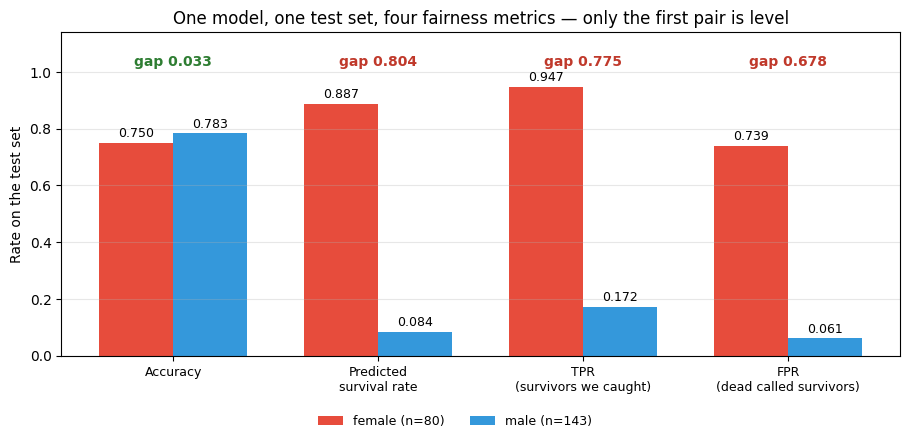

In [3]:
# WHAT: split every metric by group - accuracy, predicted-positive rate (demographic
#       parity), and the error profile (TPR = of those who really survived, how many did we
#       catch; FPR = of those who really died, how many did we wrongly call survivors).
# WHY: fairness auditing 101 - a model can look fine on one metric and be wildly unequal on
#      another. Real data is where those metrics start disagreeing with each other.

import matplotlib.pyplot as plt


def group_report(y_true, y_hat, mask):
    """Return the per-group metrics for one boolean mask over the test set."""
    yt, yp = np.asarray(y_true)[mask], np.asarray(y_hat)[mask]
    tp = int(((yt == 1) & (yp == 1)).sum())
    fn = int(((yt == 1) & (yp == 0)).sum())
    fp = int(((yt == 0) & (yp == 1)).sum())
    tn = int(((yt == 0) & (yp == 0)).sum())
    return {'n': int(mask.sum()),
            'accuracy': (tp + tn) / max(mask.sum(), 1),
            'predicted_survival_rate': yp.mean(),      # demographic parity term
            'actual_survival_rate': yt.mean(),         # what history recorded
            'TPR': tp / max(tp + fn, 1),
            'FPR': fp / max(fp + tn, 1)}

masks = {g: (g_test == g).values for g in ['female', 'male']}
rep = {g: group_report(y_test, y_pred, m) for g, m in masks.items()}

print(f"{'group':8s} {'n':>4s} {'accuracy':>9s} {'pred rate':>10s} {'actual':>8s} {'TPR':>7s} {'FPR':>7s}")
for g, r in rep.items():
    print(f"{g:8s} {r['n']:4d} {r['accuracy']:9.3f} {r['predicted_survival_rate']:10.3f} "
          f"{r['actual_survival_rate']:8.3f} {r['TPR']:7.3f} {r['FPR']:7.3f}")

acc_gap = abs(rep['female']['accuracy'] - rep['male']['accuracy'])
dp_gap = abs(rep['female']['predicted_survival_rate'] - rep['male']['predicted_survival_rate'])
tpr_gap = abs(rep['female']['TPR'] - rep['male']['TPR'])
fpr_gap = abs(rep['female']['FPR'] - rep['male']['FPR'])

print(f"\nAccuracy gap between groups   : {acc_gap:.3f}")
print(f"Demographic parity gap        : {dp_gap:.3f}")
print(f"TPR gap (equalized odds)      : {tpr_gap:.3f}")
print(f"FPR gap (equalized odds)      : {fpr_gap:.3f}")

# Let the numbers - not a pre-written story - decide what we print here.
print("\nREADING THE RESULT (computed from this run, not asserted in advance):")
if acc_gap < 0.10:
    print(f"  - Accuracy by group is nearly EQUAL ({acc_gap:.3f} apart). On that metric alone")
    print("    this model passes, and a team reporting only accuracy would ship it.")
if tpr_gap > 0.30 or fpr_gap > 0.30:
    print(f"  - But the ERROR PROFILES are not remotely equal (TPR gap {tpr_gap:.3f}, "
          f"FPR gap {fpr_gap:.3f}).")
    print(f"    For women the model says 'survived' for {rep['female']['FPR']:.0%} of those who")
    print("    actually died; for men it misses "
          f"{1 - rep['male']['TPR']:.0%} of those who actually survived.")
    print("    Equal accuracy, opposite mistakes. This is why accuracy-by-group is not enough.")
print("\n  - Note WHY the model behaves this way: it is reproducing a real historical")
print("    pattern ('women and children first' was a stated policy). A metric can only tell")
print("    you that outcomes differ. Whether a difference is *justified* is a human")
print("    judgment - and that is exactly the judgment a synthetic dataset takes away from you.")

# --- The same four numbers per group, drawn on one axis -------------------------------
# Equal-height bars within a pair = the two groups are treated the same ON THAT METRIC.
# Nothing here is new arithmetic; it is the table above, made comparable at a glance.
metrics = [('Accuracy', 'accuracy'),
           ('Predicted\nsurvival rate', 'predicted_survival_rate'),
           ('TPR\n(survivors we caught)', 'TPR'),
           ('FPR\n(dead called survivors)', 'FPR')]
xpos = np.arange(len(metrics)); width = 0.36
fig, ax = plt.subplots(figsize=(9.2, 4.4))
f_vals = [rep['female'][k] for _, k in metrics]
m_vals = [rep['male'][k] for _, k in metrics]
b1 = ax.bar(xpos - width/2, f_vals, width, color='#e74c3c', label=f"female (n={rep['female']['n']})")
b2 = ax.bar(xpos + width/2, m_vals, width, color='#3498db', label=f"male (n={rep['male']['n']})")
for bars in (b1, b2):
    ax.bar_label(bars, fmt='%.3f', fontsize=9, padding=2)
for x, (_, k) in zip(xpos, metrics):
    gap = abs(rep['female'][k] - rep['male'][k])
    ax.annotate(f"gap {gap:.3f}", xy=(x, 1.02), ha='center', fontsize=10,
                color=('#2e7d32' if gap < 0.10 else '#c0392b'), fontweight='bold')
ax.set_xticks(xpos); ax.set_xticklabels([n for n, _ in metrics], fontsize=9)
ax.set_ylim(0, 1.14); ax.set_ylabel('Rate on the test set')
ax.set_title('One model, one test set, four fairness metrics — only the first pair is level',
             fontsize=12)
ax.grid(axis='y', alpha=0.3)
# Legend below the axes: the top of the plot belongs to the gap row.
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.01))
fig.tight_layout(rect=(0, 0.06, 1, 1)); plt.show()


**Read the figure — it is the argument of this whole notebook in one picture.**

Look at the **first pair only**: two bars of almost the same height, a gap of 0.033. On accuracy by
group, this model passes. That is the audit most teams run, and it is where most audits stop.

Now look at the other three pairs. **Predicted survival rate**: 0.887 against 0.084 — the model says
"survived" for nearly nine women in ten and fewer than one man in ten. **TPR**: it catches 95% of the
women who really survived and 17% of the men who did. **FPR**: it wrongly promises survival to 74% of
the women who actually died, against 6% of the men. Same overall accuracy, opposite mistakes.

Three of the four gaps are printed in red because they exceed 0.10; one is green. **A model can be
called fair or unfair on this single test set depending on which bar pair you photograph for the
slide** — which is why "we checked for bias" is not a finding until it names the metric. Note also that
the model is not malfunctioning: it is reproducing "women and children first". Detecting a difference
and judging it unjust are two different acts, and only the first one is arithmetic.

## 🌍 Real-World Worked Example — the audit a regulator actually asks for

**Industry context (all real incidents — figures as the original sources give them):**
- **Amazon's résumé-screening tool.** Built from 2014; by 2015 Amazon found it was not rating candidates for software-developer and other technical posts in a gender-neutral way, because it had learned from ten years of résumés that came mostly from men. It downgraded résumés containing the word "women's". The project was scrapped in 2017 and reported by Reuters (Jeffrey Dastin) on 10 October 2018.
- **A US healthcare risk model.** Obermeyer, Powers, Vogeli & Mullainathan (*Science* 366(6464), 447-453, 2019) found that at a given risk score Black patients were considerably sicker than White patients, because the algorithm predicted health-care **cost** rather than illness. Removing the bias would raise the share of Black patients referred for extra help **from 17.7% to 46.5%**.
- **COMPAS recidivism scores.** ProPublica (Angwin, Larson, Mattu & Kirchner, 23 May 2016) reported that **44.9%** of Black defendants who did not re-offend had been labelled higher risk, against **23.5%** of White defendants — and the mirror-image error ran the other way (**47.7%** of White re-offenders labelled low risk, against **28.0%** of Black re-offenders). The vendor, Northpointe, replied in July 2016 (Dieterich, Mendoza & Brennan, *COMPAS Risk Scales: Demonstrating Accuracy Equity and Predictive Parity*) that the scores are equally *calibrated* across races — a different fairness definition, which both sides can satisfy at once only in special cases. That disagreement is itself the lesson.

The standard first move when a model is flagged is **"delete the protected attribute"** —
so-called *fairness through unawareness*. Below we actually try it on the real data and
measure **all** of the consequences, not only the flattering one.


model           overall   acc F   acc M  rate F  rate M  DP gap   TPR F   TPR M
Sees Sex          0.771   0.750   0.783   0.887   0.084   0.804   0.947   0.172
Sex removed       0.682   0.537   0.762   0.300   0.231   0.069   0.386   0.483


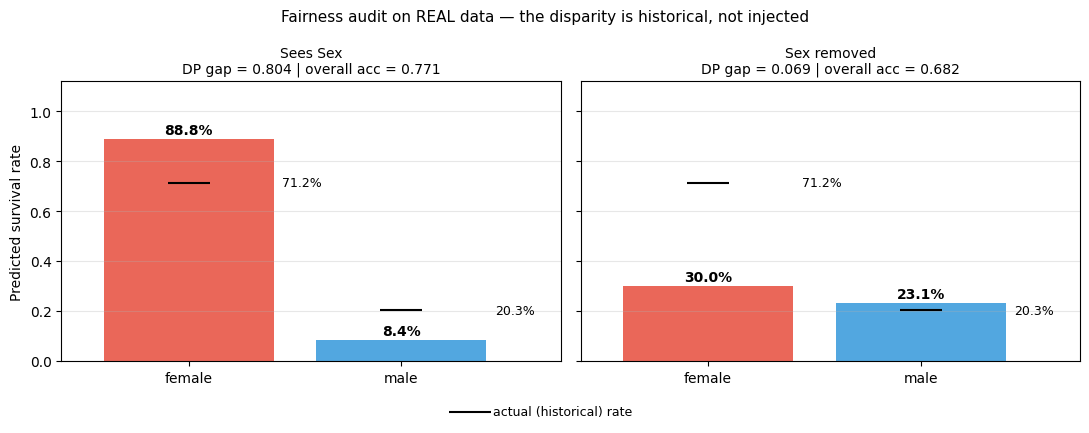


INTERPRETABILITY - standardised logistic-regression coefficients (model that sees Sex):
  Sex_male       -1.260
  Pclass         -0.932
  Age            -0.524
  SibSp          -0.253
  Embarked_S     -0.155
  Fare           +0.131
  Embarked_Q     +0.081
  Parch          -0.035


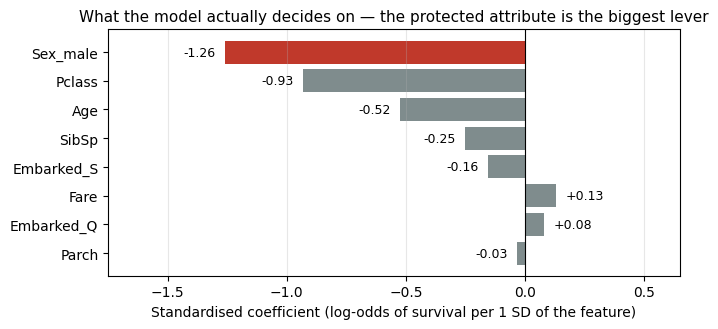


WHAT DELETING THE PROTECTED ATTRIBUTE ACTUALLY DID (this run):
  demographic parity gap : 0.804 -> 0.069  (reduced by 0.734)
  overall accuracy       : 0.771 -> 0.682  (lost 0.090)
  accuracy for women     : 0.750 -> 0.537  (lost 0.213)
  accuracy for men       : 0.783 -> 0.762  (lost 0.021)

  So: the 'fix' DID shrink the parity gap - and it paid for that almost entirely
  out of the accuracy of one group. The blinded model buys parity by refusing to
  predict survival for women who did in fact survive. A slide saying only
  'removing the attribute reduced disparity' would be true and deeply misleading.

  Also note the parity gap does NOT fall to zero: fare, class and family size are
  proxies that carry part of the signal anyway. Deleting a column does not delete a
  correlation. Practitioners use Fairlearn (Microsoft) or AI Fairness 360 (IBM) to
  optimise a chosen fairness constraint explicitly instead of hoping unawareness works.


In [4]:
# WHAT/WHY: train two models on the SAME real passengers - one that sees `Sex`, one that
# does not - and compare them on every metric, including the ones that make the "fix" look
# bad. Anything less than the full table is advocacy, not an audit.
import matplotlib.pyplot as plt

# The blinded feature set: identical to the aware one minus the protected column.
X_train_blind = X_train.drop(columns=['Sex_male'])
X_test_blind = X_test.drop(columns=['Sex_male'])

clf_blind = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
clf_blind.fit(X_train_blind, y_train)
y_pred_blind = clf_blind.predict(X_test_blind)

# Score both models with the same per-group function used in Step 3.
rep_blind = {g: group_report(y_test, y_pred_blind, m) for g, m in masks.items()}
models = {'Sees Sex': (y_pred, rep), 'Sex removed': (y_pred_blind, rep_blind)}

print(f"{'model':14s} {'overall':>8s} {'acc F':>7s} {'acc M':>7s} {'rate F':>7s} "
      f"{'rate M':>7s} {'DP gap':>7s} {'TPR F':>7s} {'TPR M':>7s}")
summary = {}
for name, (pred, r) in models.items():
    dp = abs(r['female']['predicted_survival_rate'] - r['male']['predicted_survival_rate'])
    summary[name] = {'overall': accuracy_score(y_test, pred), 'dp': dp, 'rep': r}
    print(f"{name:14s} {summary[name]['overall']:8.3f} {r['female']['accuracy']:7.3f} "
          f"{r['male']['accuracy']:7.3f} {r['female']['predicted_survival_rate']:7.3f} "
          f"{r['male']['predicted_survival_rate']:7.3f} {dp:7.3f} "
          f"{r['female']['TPR']:7.3f} {r['male']['TPR']:7.3f}")

# --- Visualise: predicted survival rate by group, with the historical rate as reference ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (name, (pred, r)) in zip(axes, models.items()):
    rates = [r['female']['predicted_survival_rate'], r['male']['predicted_survival_rate']]
    actual = [r['female']['actual_survival_rate'], r['male']['actual_survival_rate']]
    bars = ax.bar(['female', 'male'], rates, color=['#e74c3c', '#3498db'], alpha=0.85)
    # Black ticks mark what actually happened - the model bars should be read against these.
    ax.scatter(['female', 'male'], actual, color='black', zorder=5, marker='_', s=900,
               label='actual (historical) rate')
    for x, a in zip([0, 1], actual):
        # Sit the label clear of the bar (bars are 0.8 wide) so it can never overlap it.
        ax.text(x + 0.44, a, f"{a:.1%}", va='center', ha='left', fontsize=9)
    ax.set_ylim(0, 1.12); ax.set_xlim(-0.6, 1.75)
    ax.set_title(f"{name}\nDP gap = {summary[name]['dp']:.3f} | overall acc = "
                 f"{summary[name]['overall']:.3f}", fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, rate + 0.02, f"{rate:.1%}",
                ha='center', fontweight='bold')
axes[0].set_ylabel('Predicted survival rate')
# One legend for both panels, parked below the axes so it cannot sit on top of the data.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=1, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Fairness audit on REAL data — the disparity is historical, not injected', fontsize=11)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

# --- Interpretability: which feature actually drives the decision? ---
# For a linear model on standardised inputs the coefficient IS the explanation: it is the
# log-odds change per standard deviation of that feature. This is the cheapest honest
# answer to "why did the model decide that?" (SHAP/LIME generalise it to non-linear models).
print("\nINTERPRETABILITY - standardised logistic-regression coefficients (model that sees Sex):")
coefs = sorted(zip(X_train.columns, clf[-1].coef_[0]), key=lambda t: -abs(t[1]))
for name, coef in coefs:
    print(f"  {name:14s} {coef:+.3f}")

# The same numbers as a picture: length = how much the feature moves the decision,
# side = which way. The protected attribute should not need a caption to be spotted.
names = [n for n, _ in coefs][::-1]
vals = [c for _, c in coefs][::-1]
fig, ax = plt.subplots(figsize=(7.0, 3.4))
colors = ['#c0392b' if n == 'Sex_male' else '#7f8c8d' for n in names]
ax.barh(names, vals, color=colors)
ax.axvline(0, color='black', lw=0.8)
for y, v in enumerate(vals):
    ax.text(v + (0.04 if v >= 0 else -0.04), y, f"{v:+.2f}", va='center',
            ha='left' if v >= 0 else 'right', fontsize=9)
ax.set_xlim(-1.75, 0.65)
ax.set_xlabel("Standardised coefficient (log-odds of survival per 1 SD of the feature)")
ax.set_title("What the model actually decides on — the protected attribute is the biggest lever",
             fontsize=11)
ax.grid(axis='x', alpha=0.3)
fig.tight_layout(); plt.show()

# --- The honest verdict, computed rather than pre-written ---
d_dp = summary['Sees Sex']['dp'] - summary['Sex removed']['dp']
d_acc = summary['Sees Sex']['overall'] - summary['Sex removed']['overall']
d_accF = (summary['Sees Sex']['rep']['female']['accuracy']
          - summary['Sex removed']['rep']['female']['accuracy'])
d_accM = (summary['Sees Sex']['rep']['male']['accuracy']
          - summary['Sex removed']['rep']['male']['accuracy'])
print("\nWHAT DELETING THE PROTECTED ATTRIBUTE ACTUALLY DID (this run):")
print(f"  demographic parity gap : {summary['Sees Sex']['dp']:.3f} -> "
      f"{summary['Sex removed']['dp']:.3f}  ({'reduced' if d_dp > 0 else 'increased'} "
      f"by {abs(d_dp):.3f})")
print(f"  overall accuracy       : {summary['Sees Sex']['overall']:.3f} -> "
      f"{summary['Sex removed']['overall']:.3f}  ({'lost' if d_acc > 0 else 'gained'} "
      f"{abs(d_acc):.3f})")
print(f"  accuracy for women     : {summary['Sees Sex']['rep']['female']['accuracy']:.3f} -> "
      f"{summary['Sex removed']['rep']['female']['accuracy']:.3f}  "
      f"({'lost' if d_accF > 0 else 'gained'} {abs(d_accF):.3f})")
print(f"  accuracy for men       : {summary['Sees Sex']['rep']['male']['accuracy']:.3f} -> "
      f"{summary['Sex removed']['rep']['male']['accuracy']:.3f}  "
      f"({'lost' if d_accM > 0 else 'gained'} {abs(d_accM):.3f})")
if d_dp > 0 and d_accF > d_accM:
    print("\n  So: the 'fix' DID shrink the parity gap - and it paid for that almost entirely")
    print("  out of the accuracy of one group. The blinded model buys parity by refusing to")
    print("  predict survival for women who did in fact survive. A slide saying only")
    print("  'removing the attribute reduced disparity' would be true and deeply misleading.")
print("\n  Also note the parity gap does NOT fall to zero: fare, class and family size are")
print("  proxies that carry part of the signal anyway. Deleting a column does not delete a")
print("  correlation. Practitioners use Fairlearn (Microsoft) or AI Fairness 360 (IBM) to")
print("  optimise a chosen fairness constraint explicitly instead of hoping unawareness works.")


**Read the figure.** Coloured bars are what the **model predicts**; the black dashes are what
**actually happened** to those passengers.

*Left panel — the model that sees `Sex`.* Each bar sits on the same side of its dash as history does:
it over-predicts survival for women (88.8% against a real 71.2%) and under-predicts it for men (8.4%
against 20.3%). Its two bars are 0.804 apart.

*Right panel — the same model with the `Sex` column deleted.* The two bars have collapsed toward each
other (30.0% and 23.1%, a gap of 0.069) — but look at *how*. The male bar barely moved and still lands
near its dash; the female bar fell from 88.8% to 30.0%, now **41 points below** what actually happened
to those women. Parity was bought almost entirely out of one group, and the printed table names the
price: overall accuracy 0.771 → 0.682, accuracy for women 0.750 → 0.537, accuracy for men 0.783 → 0.762.

Two honest readings follow. The parity gap did not reach zero, because fare, class and family size
still carry the signal — deleting a column does not delete a correlation. And a slide showing only the
right panel, captioned "we removed the bias", would be literally true and profoundly misleading.

**And the third figure, the interpretability one.** For a linear model on standardised inputs the
coefficient *is* the explanation — how far the log-odds of survival move per standard deviation of that
feature. `Sex_male` is the longest bar by a clear margin (−1.26, against −0.93 for ticket class and
−0.52 for age), which is the mechanical reason deleting that column cost so much accuracy: it was the
model's single biggest lever. This is the cheapest honest answer to "why did the model decide that?",
and SHAP and LIME exist to give you the same kind of answer for models whose coefficients you cannot
read.

## 🧩 Mini-exercise

**Try it:** Re-run the audit with `Pclass` as the protected attribute instead of `Sex`
(1st vs 3rd class). Compute the same five numbers. Does the "delete the column" fix behave
the same way? Then try sub-sampling one group down to 100 rows before training and see which
metric degrades first.

---

## ✅ Summary

**What you did:** Audited a classifier trained on **891 real passengers** — overall accuracy,
**accuracy per group**, **demographic parity**, and **per-group TPR/FPR** — then tested the
most common "fix" and measured what it cost.

**What the real data actually showed (read your own output above, the numbers are computed):**
1. **Accuracy by group was nearly equal while the error profiles were not.** The model was
   about as accurate for women as for men, yet it over-predicted survival for women and
   under-predicted it for men. A single fairness metric will pass models that another fails.
2. **Deleting the protected attribute reduced the parity gap but did not zero it** — fare,
   class and family size are proxies — and it **cost accuracy, most of it from one group**.
   Mitigation is a trade-off you must state, not a box you tick.
3. **A measured disparity is not a proven injustice.** "Women and children first" was an
   announced policy. Metrics detect that outcomes differ; deciding whether that difference
   is acceptable is a human judgment about context.

**The epistemic point:** none of the above was put into the data by this notebook. A
synthetic "biased dataset" with a hand-tuned group penalty can only give you back the number
its author chose — the audit is circular, and the messy disagreements between metrics that
make real fairness work hard never appear.

**In real life you'd also:** apply explicit fairness constraints or reweighting (Fairlearn,
AIF360) rather than unawareness, and use SHAP/LIME for per-prediction explanations of
non-linear models.

**Next:** `01_gans_and_autoencoders_vaes` and `03_reinforcement_learning_fundamentals_deep_q_networks_policy_gradients` cover other Unit 4 topics.


## 📚 References

1. Ribeiro, M. T., Singh, S. & Guestrin, C. (2016). *"Why Should I Trust You?": Explaining the Predictions of Any Classifier* (LIME). KDD. https://arxiv.org/abs/1602.04938
2. Lundberg, S. M. & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions* (SHAP). NeurIPS. https://arxiv.org/abs/1705.07874
3. Hardt, M., Price, E. & Srebro, N. (2016). *Equality of Opportunity in Supervised Learning* (equalized odds, TPR/FPR by group). NeurIPS. https://arxiv.org/abs/1610.02413
4. Dwork, C., Hardt, M., Pitassi, T., Reingold, O. & Zemel, R. (2012). *Fairness Through Awareness* (why "unawareness" fails). ITCS. https://arxiv.org/abs/1104.3913
5. Obermeyer, Z., Powers, B., Vogeli, C. & Mullainathan, S. (2019). *Dissecting racial bias in an algorithm used to manage the health of populations*. Science 366(6464). https://www.science.org/doi/10.1126/science.aax2342
6. Mehrabi, N. et al. (2021). *A Survey on Bias and Fairness in Machine Learning*. ACM Computing Surveys 54(6). https://arxiv.org/abs/1908.09635
7. Barocas, S., Hardt, M. & Narayanan, A. (2023). *Fairness and Machine Learning: Limitations and Opportunities*. MIT Press. https://fairmlbook.org/
8. Angwin, J., Larson, J., Mattu, S. & Kirchner, L. (2016). *Machine Bias*. ProPublica, 23 May 2016. https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing (and the vendor's reply: Dieterich, W., Mendoza, C. & Brennan, T. (2016). *COMPAS Risk Scales: Demonstrating Accuracy Equity and Predictive Parity*. Northpointe.)
9. Dastin, J. (2018). *Amazon scraps secret AI recruiting tool that showed bias against women*. Reuters, 10 October 2018.
10. Chouldechova, A. (2017). *Fair prediction with disparate impact: A study of bias in recidivism prediction instruments*. Big Data 5(2), 153-163. https://arxiv.org/abs/1703.00056 — why calibration and equal error rates cannot both hold when base rates differ.

**Recent work (2024–2026)**

11. Chen et al. (2025). *Reasoning Models Don't Always Say What They Think*. arXiv. https://arxiv.org/abs/2505.05410 — decisive for any 2026 interpretability claim: a model's visible chain of thought is not a faithful account of the computation that produced the answer, so it is not an explanation.
12. Ghosh et al. (2026). *Evaluation Cards: An Interpretive Layer for AI Evaluation Reporting*. arXiv. https://arxiv.org/abs/2606.09809 — standardises *evaluation* reporting the way model cards standardised model reporting — the natural next artifact after a fairness audit.
